# TP1

In [1]:
from src.utils import retrieve_patterns
from src.hopfield import Hopfield
from src.pattern import Pattern
from collections import defaultdict


patterns = defaultdict(list)
for pattern in retrieve_patterns("images"):
    patterns[len(pattern)].append(pattern)

models = {}
for size, ps in patterns.items():
    m = Hopfield(size)
    m.train(ps)
    models[size] = m

Parto el dataset de patrones en 2, entrenando un modelo para cada set de datos con distintas dimensiones

## Imágenes

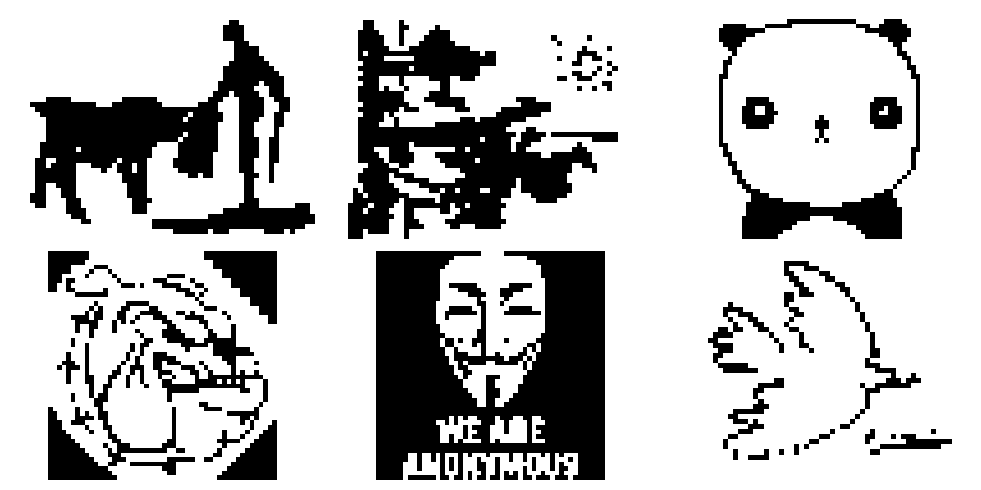

In [2]:
import matplotlib.pyplot as plt
from src.utils import retrieve_images


images = list(retrieve_images("images"))
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

for ax, image in zip(axes.flat, images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

## a) Verifique si la red aprendió las imágenes enseñadas

In [3]:
for size, m in models.items():
    ps = patterns[size]

    for p in ps:
        if not m.is_stable(p):
            raise Exception(f"network failed to learn {p.name}")

Dado que no tiró la excepción, podemos confirmar que los patrones son estados estables en sus respectivas redes, o en criollo, las redes aprendieron las imágenes.

## b) Evalúe la evolución de la red al presentarle versiones alteradas de las imágenes aprendidas: agregado de ruido, elementos borrados o agregados.

In [4]:
import matplotlib.pyplot as plt
from typing import Callable, Iterable
from math import sqrt


def recall_metrics_with(m: Hopfield, p: Pattern, f: Callable) -> tuple[int, int]:
    closest, steps = m.recall(f(p))
    dist = sum(int(closest[i] != p[i]) for i in range(len(p)))
    return closest, steps, dist


def steps_dists_to_converge(size: int, ks: Iterable[int], f: Callable) -> tuple[list[float], list[float]]:
    ps = patterns[size]
    m = models[size]

    steps, dists = [], []

    for k in ks:
        k = min(k, size)
        steps_sum, dists_sum = 0, 0

        for p in ps:
            _, steps_taken, dist = recall_metrics_with(m, p, lambda x: f(x, k))
            steps_sum += steps_taken
            dists_sum += dist

        steps.append(steps_sum / len(ps))
        dists.append(dists_sum / len(ps))

    return steps, dists


def plot(size: int, f: Callable, xlabel: str):
    ks = range(0, size + 1, size // 10)
    steps, dists = steps_dists_to_converge(size, ks, flip_bytes)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(ks, dists)
    ax1.set_title(f"Mean distances to the original pattern")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Hamming distance (neurons)")

    ax2.plot(ks, steps)
    ax2.set_title(f"Mean steps to converge")
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("Steps taken to converge")

    fig.suptitle(f"Hopfield Network with {size} neurons", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### Neuronas invertidas

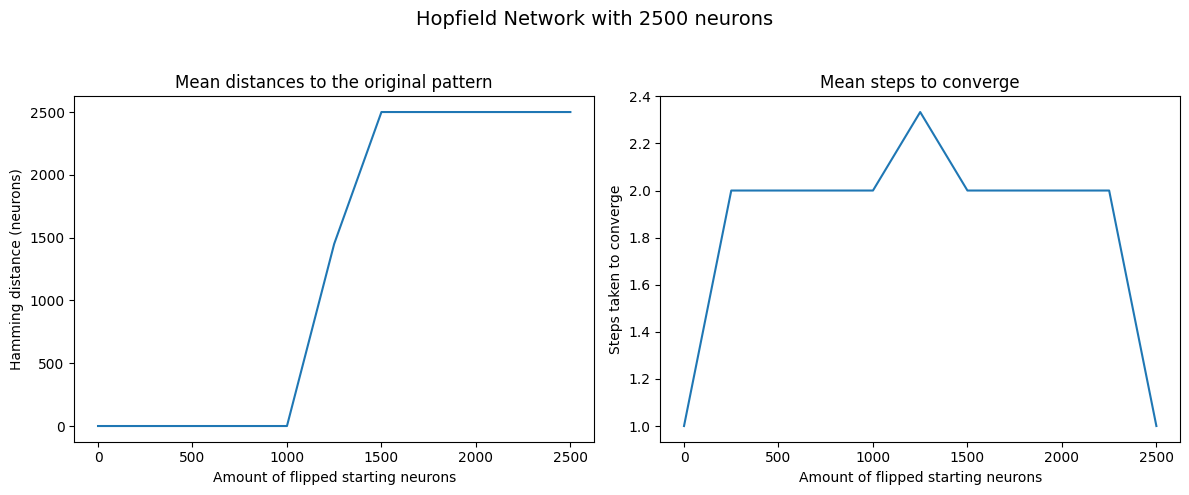

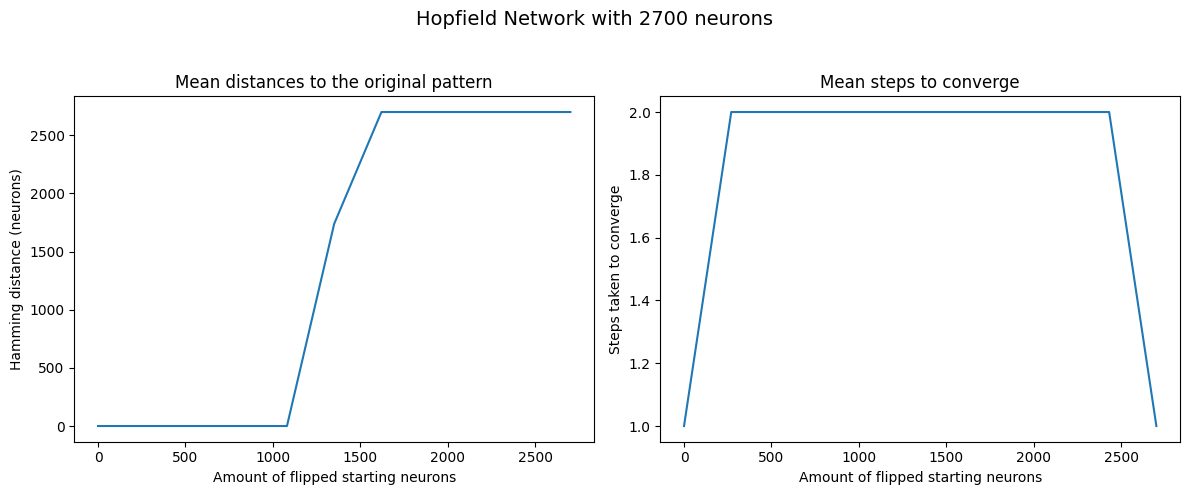

In [5]:
from src.utils import flip_bytes

for size in sorted(patterns):
    plot(size, flip_bytes, "Amount of flipped starting neurons")

#### Neuronas seteadas a 1

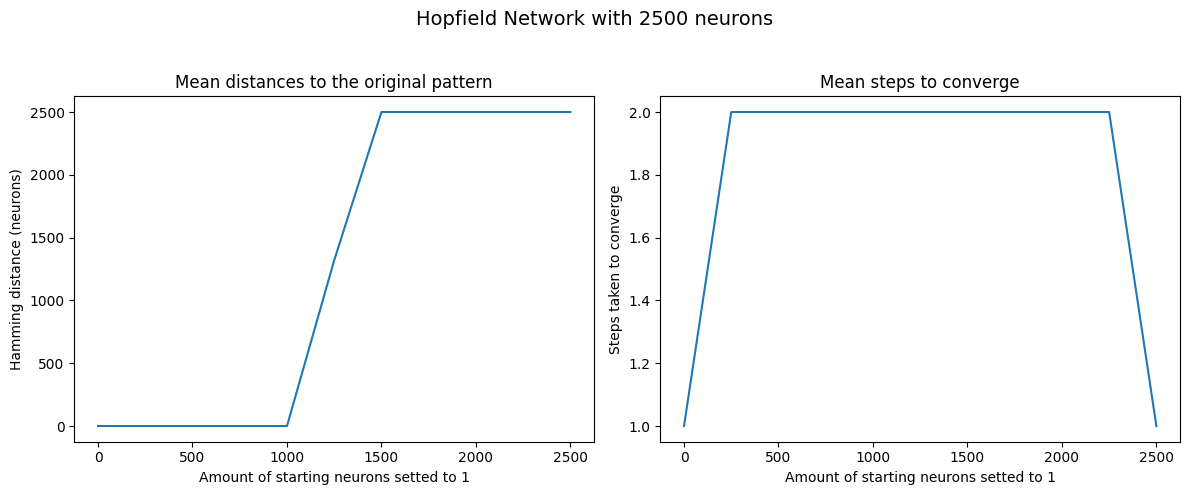

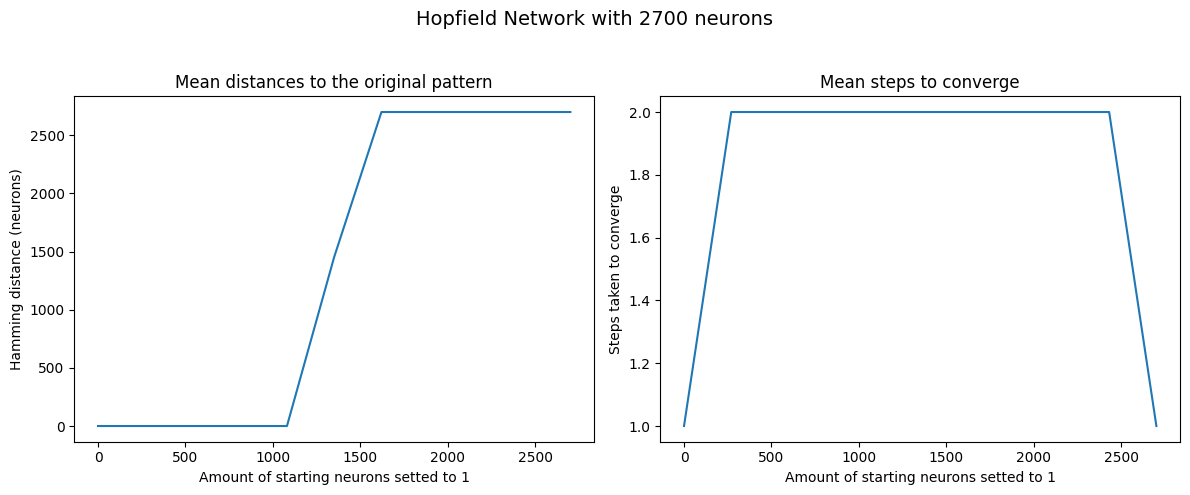

In [6]:
from src.utils import paint_bytes

for size in sorted(patterns):
    plot(size, lambda p, k: paint_bytes(p, k, 1), "Amount of starting neurons setted to 1")

#### Neuronas seteadas a -1

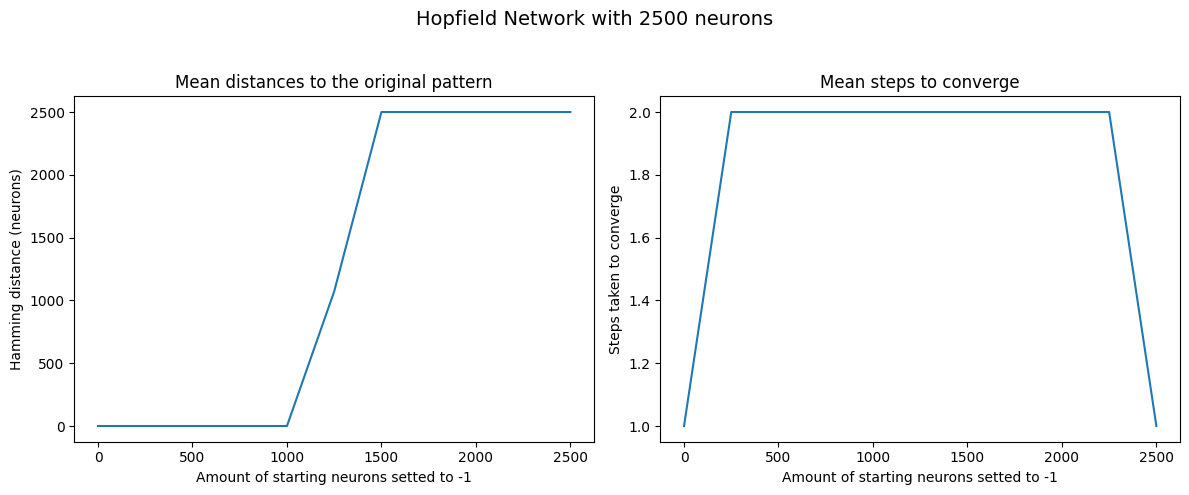

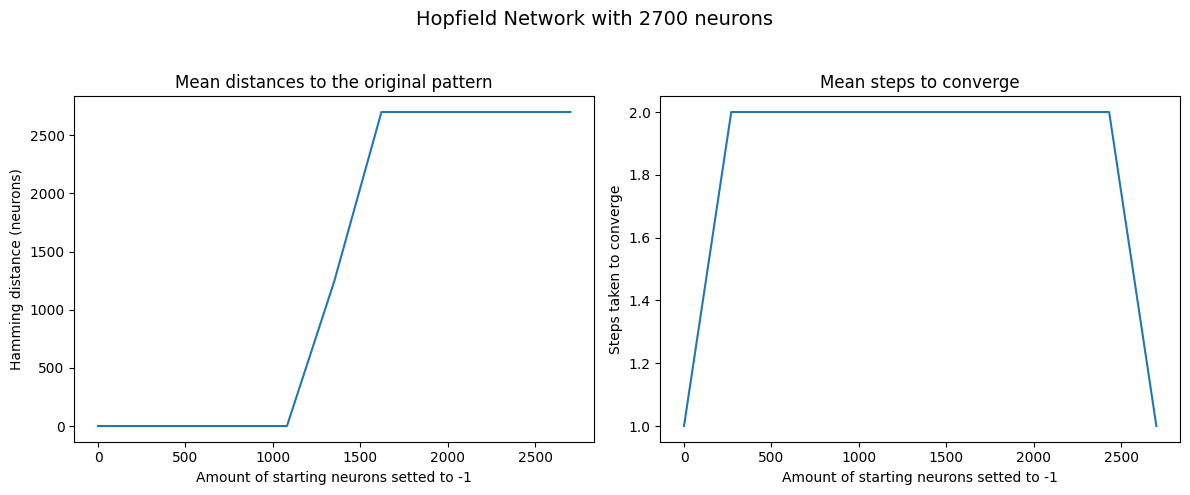

In [7]:
from src.utils import paint_bytes

for size in sorted(patterns):
    plot(size, lambda p, k: paint_bytes(p, k, -1), "Amount of starting neurons setted to -1")

Ambas redes se comportan como deberían, una vez pasado el umbral de la mitad de neuronas invertidas, el atractor inverso queda más cerca por lo que converge hacia allá.

## c) Evalúe la existencia de estados espurios en la red: patrones inversos y combinaciones de un número impar de patrones. (Ver Spurious States, en la sección 2.2, Hertz, Krogh & Palmer, pág. 24).

#### Patrones inversos

In [8]:
for size, m in models.items():
    ps = patterns[size]

    for p in ps:
        if not m.is_stable(-p):
            raise Exception(f"{p.name} is not a spurious state")

#### Combinaciones de un número impar de patrones

In [9]:
from src.utils import all_linear_combs


for size, m in models.items():
    combs = all_linear_combs(patterns[size])
    
    for p in combs:
        if not m.is_stable(p):
            raise Exception(f"{p.name} is not a spurious state")

Para las combinaciones de patrones decidí usar todas las combinaciones y efectivamente todos ellos son estados estables en la red

## d) Realice un entrenamiento con las 6 imágenes disponibles. ¿Es capaz la red de aprender todas las imágenes? Explique

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Iterable


def recall_metrics(m: Hopfield, p: Pattern) -> tuple[int, int]:
    closest, steps = m.recall(p)
    dist = sum(int(closest[i] != p[i]) for i in range(len(p)))
    return closest, steps, dist


def plot_if_different(m: Hopfield, p: Pattern):
    recalled, steps, dist = recall_metrics(m, p)
    if dist == 0:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    p_arr = np.array(p).reshape(p.shape())
    ax1.imshow((p_arr + 1) // 2, cmap="gray", interpolation="nearest")
    ax1.set_title("Original")
    ax1.axis("off")

    r_arr = np.array(recalled).reshape(recalled.shape())
    ax2.imshow((r_arr + 1) // 2, cmap="gray", interpolation="nearest")
    ax2.set_title(f"Recalled")
    ax2.axis("off")

    fig.suptitle(f"Took {steps} steps to reach a state with a Hamming distance of {dist} for {p.name}", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

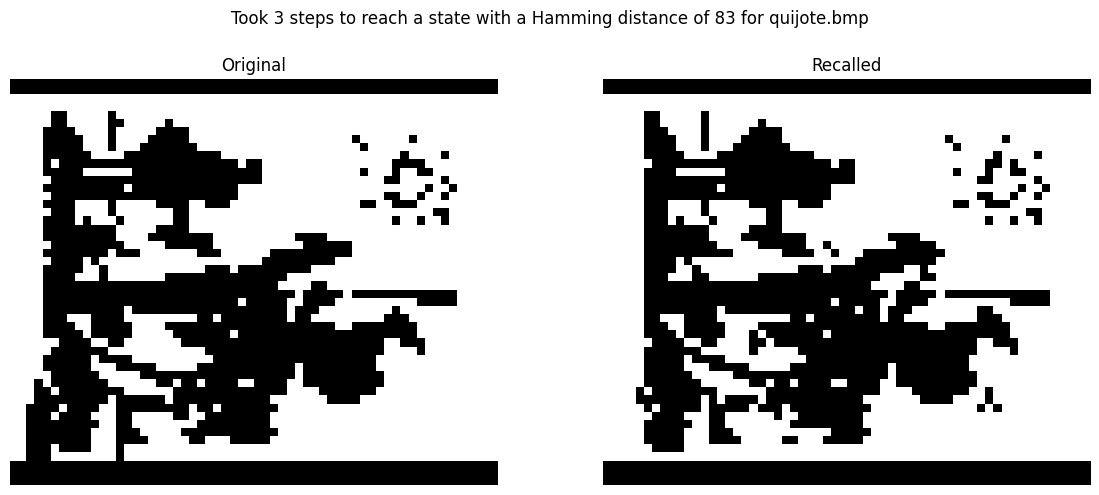

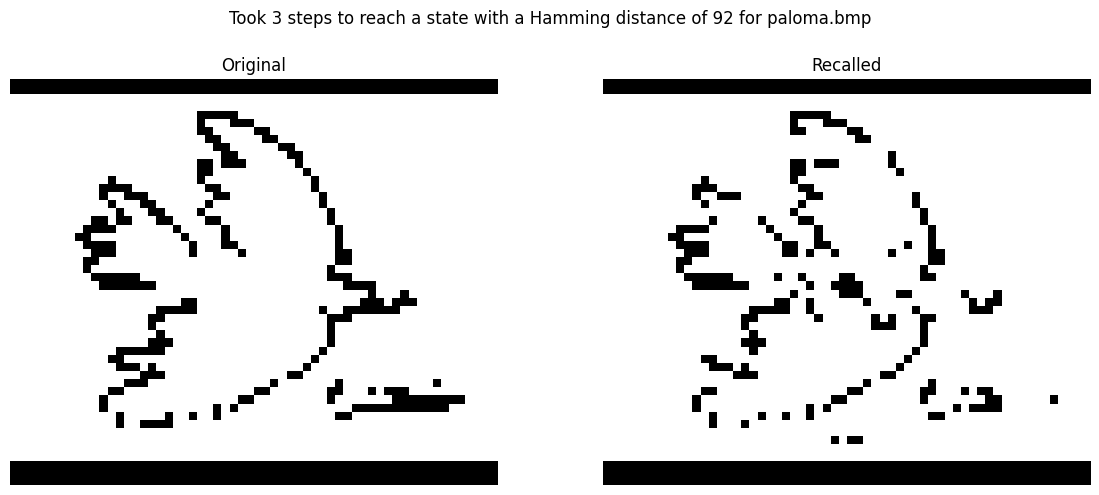

In [11]:
from src.utils import retrieve_patterns


mheight = max(im.shape[0] for im in images)
mwidth = max(im.shape[1] for im in images)

shape = (mwidth, mheight)
m = Hopfield(mwidth * mheight)

padded = list(retrieve_patterns("images", (mwidth, mheight)))
m.train(padded)

for p in padded:
    plot_if_different(m, p)

El modelo logra aprender 4 de las 6 imágenes. Yo elegí agregar información a cada una de ellas para lograr tener el mismo tamaño en todas ellas, seguramente cortarlas haga que sea más facil para el modelo aprenderlas, aunque no me parece válido porque estamos buscando que aprenda las imágenes, no versiones reducidas.

Entiendo que no logra aprenderlas todas por la capacidad de la red, aunque esta vez es aún más grande que los modelos anteriores, especificamente tiene 3000 neuronas, cosa que los modelos anteriores tenian 2500 y 2700. Es verdad que estábamos almacenando 3 patrones en cada uno, esta vez son el doble.

Me sorprende un poco que teniendo tantas neuronas no sea capaz de aprender todos los patrones, aún así el error es bastante chico si tenemos en cuenta que tenemos 3000 neuronas y una distancia de 92 unidades en el caso de la paloma, entonces estamos hablando de un 0.031% de error.